# 04 — AQI Classification Models
**Gurugram Air Quality Study (2020–2024)**

Classifies each day into one of 5 AQI categories based on CPCB PM₂.₅ breakpoints:

| Label | Category | PM₂.₅ (µg/m³) |
|---|---|---|
| 0 | Good | 0–30 |
| 1 | Moderate | 31–60 |
| 2 | Poor | 61–90 |
| 3 | Very Poor | 91–120 |
| 4 | Severe | >120 |

**Models:** Logistic Regression (baseline) → Random Forest → XGBoost  
**Output:** `outputs/classification_comparison.csv`, confusion matrix, ROC curves.

**Requires:** Run `01_data_preprocessing.ipynb` first.

In [1]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report,
                              roc_curve, auc)
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
import xgboost as xgb
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({"figure.dpi": 150, "savefig.dpi": 300, "font.size": 11})

BASE = os.getcwd()
OUT  = os.path.join(BASE, "outputs")
os.makedirs(OUT, exist_ok=True)

df = pd.read_csv(os.path.join(OUT, "merged_clean.csv"), parse_dates=["date"])
df = df.sort_values("date").reset_index(drop=True)
print(f"Loaded: {df.shape}")

Loaded: (1768, 32)


## 1. Feature Selection

In [2]:
TARGET = "AQI_label"
AQI_NAMES = ["Good", "Moderate", "Poor", "Very Poor", "Severe"]

CANDIDATE_FEATURES = [
    # Satellite
    "LST_C", "AAI", "CO", "HCHO", "NO2", "O3",
    # CPCB meteorology
    "AT (°C)", "RH (%)", "WS (m/s)", "WD (deg)", "SR (W/mt2)", "BP (mmHg)",
    # CPCB co-pollutants (available ground readings)
    "PM10 (µg/m³)", "NO2 (µg/m³)", "CO (mg/m³)", "Ozone (µg/m³)",
    # Temporal
    "month", "season_enc", "day_of_year",
]

FEATURES = [f for f in CANDIDATE_FEATURES if f in df.columns]
print(f"Features ({len(FEATURES)}): {FEATURES}")

data = df[[TARGET] + FEATURES].dropna(subset=[TARGET])
data[TARGET] = data[TARGET].astype(int)
print(f"Rows: {len(data)}")
print("Class distribution:")
print(data[TARGET].value_counts().sort_index().rename({i: AQI_NAMES[i] for i in range(5)}))

Features (19): ['LST_C', 'AAI', 'CO', 'HCHO', 'NO2', 'O3', 'AT (°C)', 'RH (%)', 'WS (m/s)', 'WD (deg)', 'SR (W/mt2)', 'BP (mmHg)', 'PM10 (µg/m³)', 'NO2 (µg/m³)', 'CO (mg/m³)', 'Ozone (µg/m³)', 'month', 'season_enc', 'day_of_year']
Rows: 1768
Class distribution:
AQI_label
Good         112
Moderate     581
Poor         372
Very Poor    286
Severe       417
Name: count, dtype: int64


## 2. Train / Test Split (stratified 80/20)

In [3]:
X_raw = data[FEATURES].values
y     = data[TARGET].values

imputer = SimpleImputer(strategy='median')
imputer.fit(X_raw)

# sklearn drops 100%-NaN columns during transform automatically
kept_mask     = ~np.isnan(imputer.statistics_)
FEATURES_USED = [f for f, k in zip(FEATURES, kept_mask) if k]
dropped       = [f for f, k in zip(FEATURES, kept_mask) if not k]
if dropped:
    print(f'Dropped all-NaN columns: {dropped}')
print(f'FEATURES_USED ({len(FEATURES_USED)}): {FEATURES_USED}')

# transform() already returns only surviving columns — do NOT slice with kept_mask
X = imputer.transform(X_raw)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

classes = sorted(np.unique(y))
print(f'Train: {len(X_train)} | Test: {len(X_test)}')

Dropped all-NaN columns: ['AT (°C)']
FEATURES_USED (18): ['LST_C', 'AAI', 'CO', 'HCHO', 'NO2', 'O3', 'RH (%)', 'WS (m/s)', 'WD (deg)', 'SR (W/mt2)', 'BP (mmHg)', 'PM10 (µg/m³)', 'NO2 (µg/m³)', 'CO (mg/m³)', 'Ozone (µg/m³)', 'month', 'season_enc', 'day_of_year']
Train: 1414 | Test: 354


## 3. Train All Models

In [4]:
def evaluate_clf(name, y_true, y_pred, elapsed):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    rec  = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1   = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    print(f"{name:<25}  Acc={acc:.3f}  Prec={prec:.3f}  Rec={rec:.3f}  F1={f1:.3f}  Time={elapsed:.1f}s")
    return {
        "Model": name,
        "Accuracy": round(acc, 3),
        "Precision (W)": round(prec, 3),
        "Recall (W)": round(rec, 3),
        "F1-Score (W)": round(f1, 3),
        "Training Time (s)": round(elapsed, 1),
    }

results = []
all_models = {}

# ── Logistic Regression (Baseline) ───────────────────────────────────────────
t0 = time.time()
lg = LogisticRegression(max_iter=500, random_state=42, class_weight="balanced")
lg.fit(X_train_sc, y_train)
y_pred_lg = lg.predict(X_test_sc)
results.append(evaluate_clf("Logistic Regression", y_test, y_pred_lg, time.time()-t0))
all_models["Logistic Regression"] = (lg, X_test_sc, y_pred_lg)

# ── Random Forest ─────────────────────────────────────────────────────────────
t0 = time.time()
rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42,
                             class_weight="balanced", n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
results.append(evaluate_clf("Random Forest", y_test, y_pred_rf, time.time()-t0))
all_models["Random Forest"] = (rf, X_test, y_pred_rf)

# ── XGBoost ───────────────────────────────────────────────────────────────────
t0 = time.time()
xgb_clf = xgb.XGBClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    use_label_encoder=False, eval_metric="mlogloss",
    random_state=42, verbosity=0
)
xgb_clf.fit(X_train, y_train)
y_pred_xgb = xgb_clf.predict(X_test)
results.append(evaluate_clf("XGBoost", y_test, y_pred_xgb, time.time()-t0))
all_models["XGBoost"] = (xgb_clf, X_test, y_pred_xgb)

Logistic Regression        Acc=0.404  Prec=0.453  Rec=0.404  F1=0.419  Time=0.0s
Random Forest              Acc=0.627  Prec=0.606  Rec=0.627  F1=0.605  Time=0.5s
XGBoost                    Acc=0.599  Prec=0.579  Rec=0.599  F1=0.578  Time=2.8s


## 4. Comparison Table (Paper-Ready)

In [5]:
results_df = pd.DataFrame(results).sort_values("F1-Score (W)", ascending=False)

print("\n══════════════════════════════════════════════════════════════")
print("        AQI CLASSIFICATION MODEL COMPARISON TABLE")
print("══════════════════════════════════════════════════════════════")
print(results_df.to_string(index=False))
print("══════════════════════════════════════════════════════════════")
print("(W) = weighted average across all 5 AQI classes")

results_df.to_csv(os.path.join(OUT, "classification_comparison.csv"), index=False)
print(f"\nSaved → outputs/classification_comparison.csv")
results_df


══════════════════════════════════════════════════════════════
        AQI CLASSIFICATION MODEL COMPARISON TABLE
══════════════════════════════════════════════════════════════
              Model  Accuracy  Precision (W)  Recall (W)  F1-Score (W)  Training Time (s)
      Random Forest     0.627          0.606       0.627         0.605                0.5
            XGBoost     0.599          0.579       0.599         0.578                2.8
Logistic Regression     0.404          0.453       0.404         0.419                0.0
══════════════════════════════════════════════════════════════
(W) = weighted average across all 5 AQI classes

Saved → outputs/classification_comparison.csv


,Model,Accuracy,Precision (W),Recall (W),F1-Score (W),Training Time (s)
1,Random Forest,0.627,0.606,0.627,0.605,0.5
2,XGBoost,0.599,0.579,0.599,0.578,2.8
0,Logistic Regression,0.404,0.453,0.404,0.419,0.0


## 5. Comparison Bar Chart

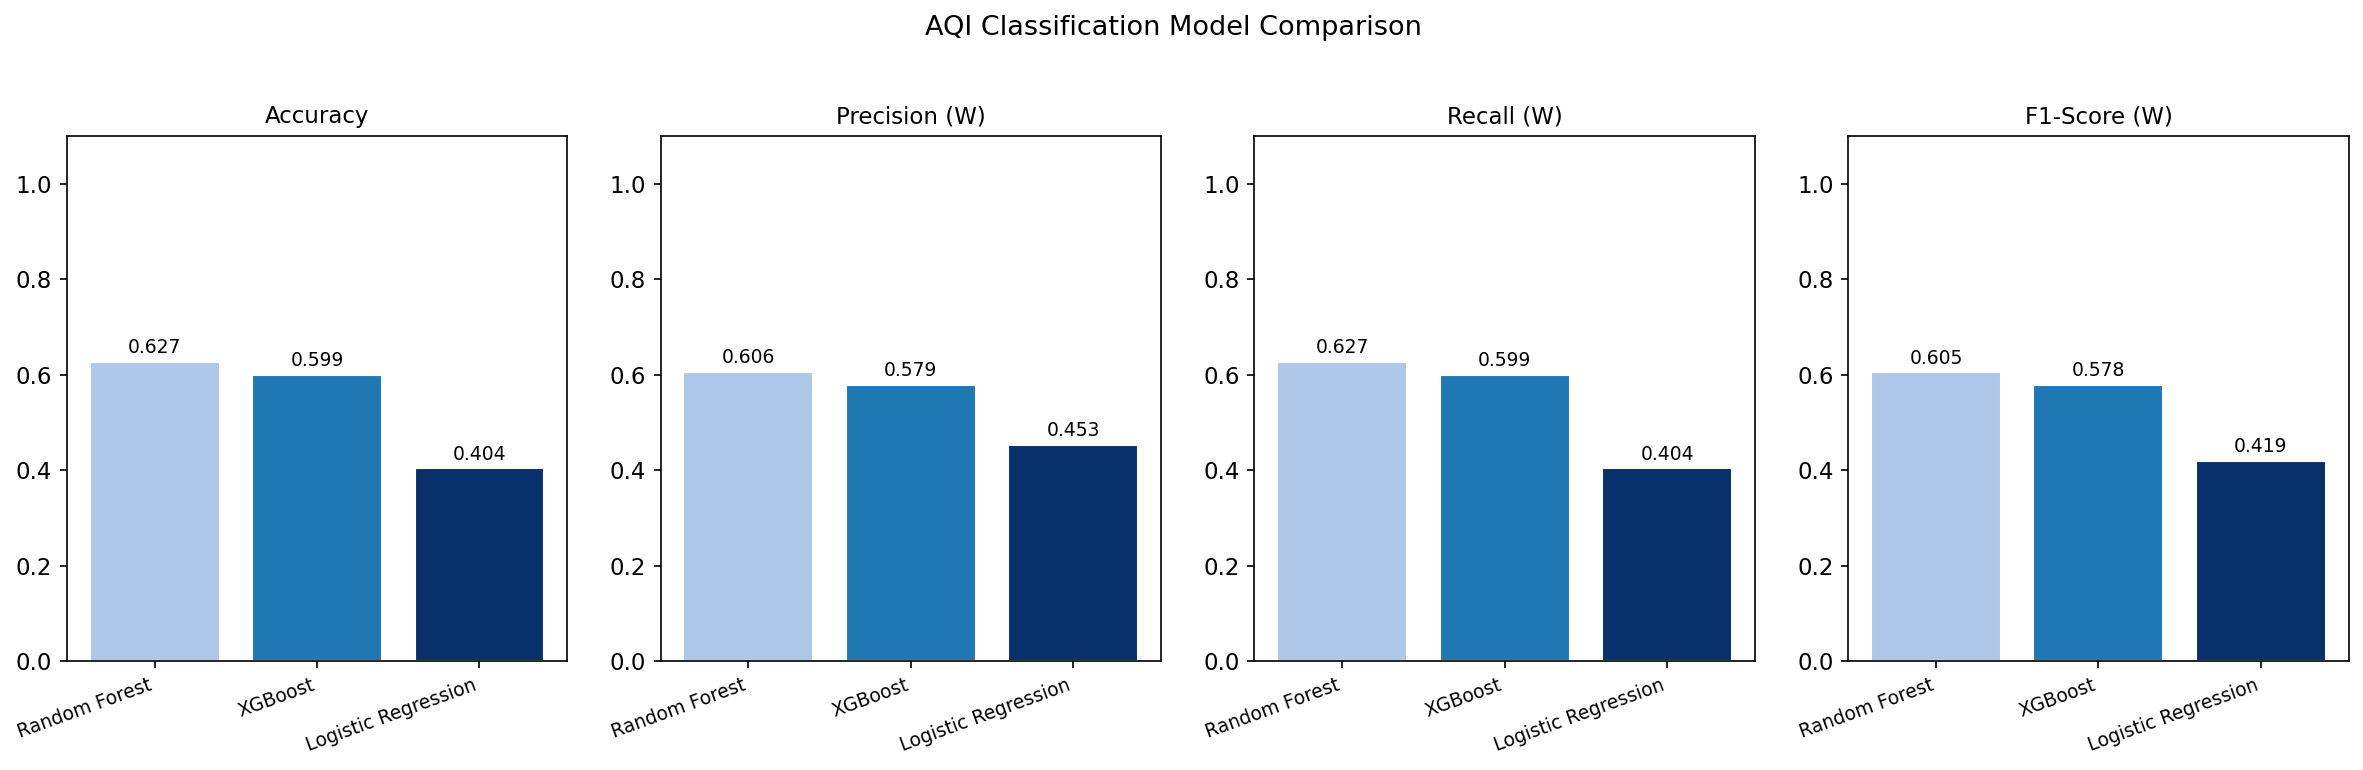

In [6]:
metrics = ["Accuracy", "Precision (W)", "Recall (W)", "F1-Score (W)"]
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
colors = ["#aec7e8", "#1f77b4", "#08306b"]

for ax, metric in zip(axes, metrics):
    vals  = results_df[metric].values
    names = results_df["Model"].values
    bars  = ax.bar(range(len(names)), vals, color=colors[:len(names)], edgecolor="white")
    ax.set_ylim(0, 1.1)
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, rotation=20, ha="right", fontsize=9)
    ax.set_title(metric, fontsize=11)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)

fig.suptitle("AQI Classification Model Comparison", fontsize=13, y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(OUT, "classification_comparison_bar.png"), bbox_inches="tight")
plt.show()

## 6. Confusion Matrix — Best Model (XGBoost)

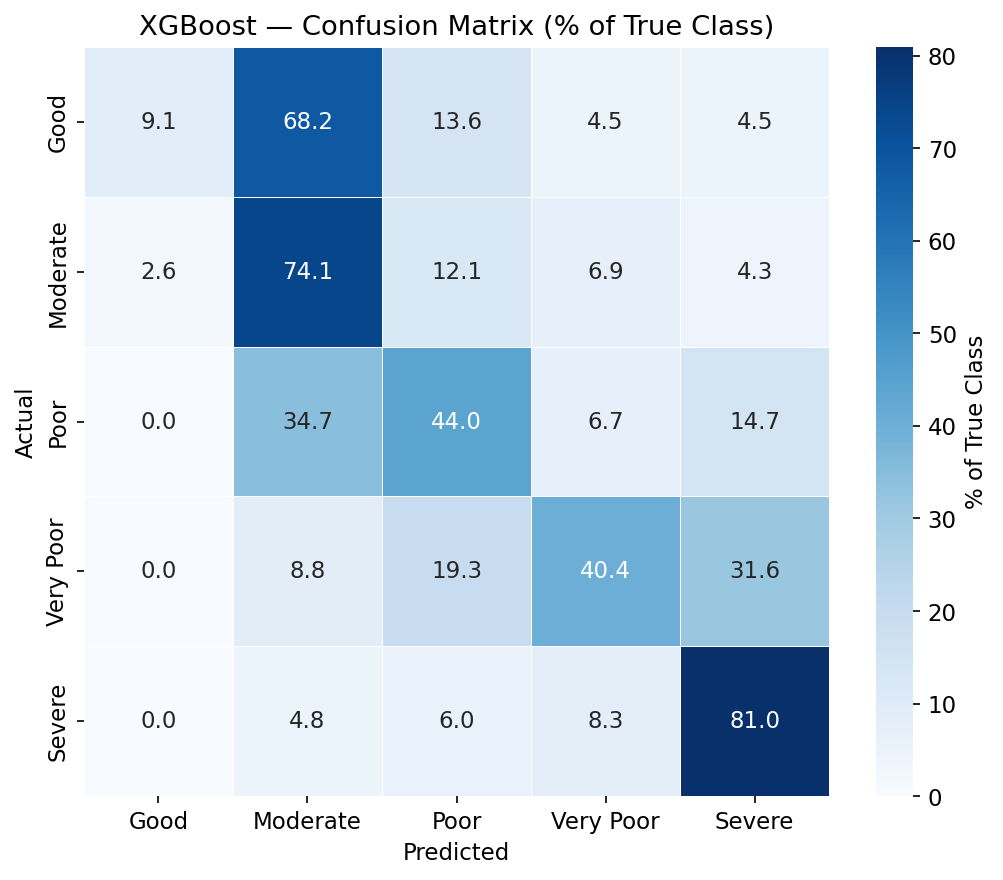


Classification Report — XGBoost
              precision    recall  f1-score   support

        Good       0.40      0.09      0.15        22
    Moderate       0.63      0.74      0.68       116
        Poor       0.50      0.44      0.47        75
   Very Poor       0.52      0.40      0.46        57
      Severe       0.66      0.81      0.73        84

    accuracy                           0.60       354
   macro avg       0.54      0.50      0.50       354
weighted avg       0.58      0.60      0.58       354



In [7]:
present_classes = sorted(np.unique(np.concatenate([y_test, y_pred_xgb])))
present_names   = [AQI_NAMES[i] for i in present_classes]

cm = confusion_matrix(y_test, y_pred_xgb, labels=present_classes)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm_pct, annot=True, fmt=".1f", cmap="Blues",
            xticklabels=present_names, yticklabels=present_names,
            linewidths=0.4, ax=ax, cbar_kws={"label": "% of True Class"})
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("XGBoost — Confusion Matrix (% of True Class)")
plt.tight_layout()
fig.savefig(os.path.join(OUT, "confusion_matrix_xgb.png"))
plt.show()

print("\nClassification Report — XGBoost")
print(classification_report(y_test, y_pred_xgb,
      target_names=present_names, zero_division=0))

## 7. ROC Curves — XGBoost (One-vs-Rest)

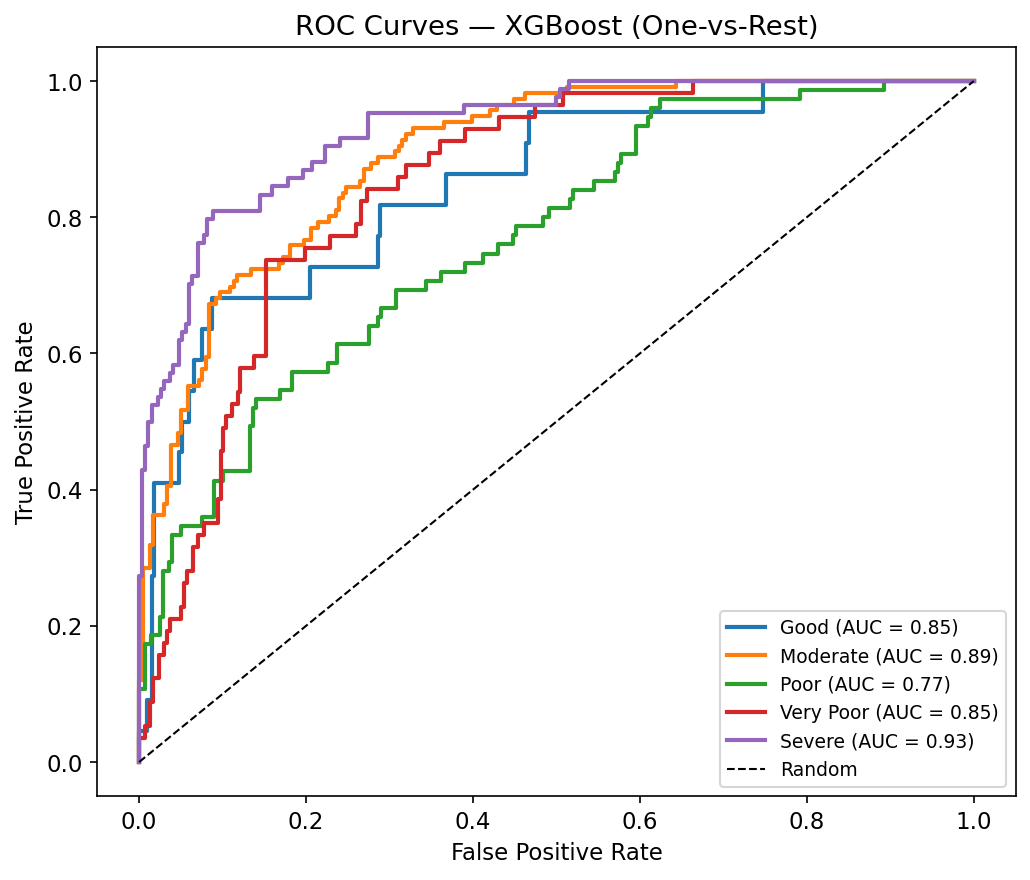

In [8]:
y_test_bin = label_binarize(y_test, classes=present_classes)
y_prob_xgb = xgb_clf.predict_proba(X_test)

# Keep only columns for present classes
all_clf_classes = list(xgb_clf.classes_)
col_idx = [all_clf_classes.index(c) for c in present_classes if c in all_clf_classes]
y_prob_xgb = y_prob_xgb[:, col_idx]

fig, ax = plt.subplots(figsize=(7, 6))
roc_colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]

for i, (cls, name) in enumerate(zip(present_classes, present_names)):
    if i >= y_test_bin.shape[1] or i >= y_prob_xgb.shape[1]:
        continue
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_xgb[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, lw=2, color=roc_colors[i % len(roc_colors)],
            label=f"{name} (AUC = {roc_auc:.2f})")

ax.plot([0,1],[0,1], "k--", lw=1, label="Random")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — XGBoost (One-vs-Rest)")
ax.legend(fontsize=9, loc="lower right")
plt.tight_layout()
fig.savefig(os.path.join(OUT, "roc_curves_xgb.png"))
plt.show()